In [1]:
SITE_ID = "Cockatoo"                
BUILDING_TYPE = "office"       
TARGET =  f"{SITE_ID}_{BUILDING_TYPE}_Giovanni"  # 明确目标列名称
DATA_SAVE_PATH = "E:/bishe/preprocessed_data（Cockatoo）.csv"  # 确保路径正确 

In [2]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import math
from time import time
import os
import warnings
warnings.filterwarnings('ignore')

Starting grid search...
Fitting 3 folds for each of 64 candidates, totalling 192 fits
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] min_data_in_leaf is set=30, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=30
[LightGBM] [Warning] lambda_l1 is set=0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0
[LightGBM] [Warning] lambda_l2 is set=0.1, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.1
Grid search completed in 18.52 seconds

Best Parameters: {'feature_fraction': 0.8, 'lambda_l1': 0, 'lambda_l2': 0.1, 'learning_rate': 0.01, 'max_depth': 7, 'min_data_in_leaf': 30, 'n_estimators': 500, 'num_leaves': 63}

Training final model with best parameters...
Training until validation scores don't improve for 50 rounds
[50]	train's rmse: 0.154487	val's rmse: 0.180635
[100]	train's rmse: 0.106309	val's rmse: 0.12646
[150]	train's rmse: 0.0788784	val's rmse:

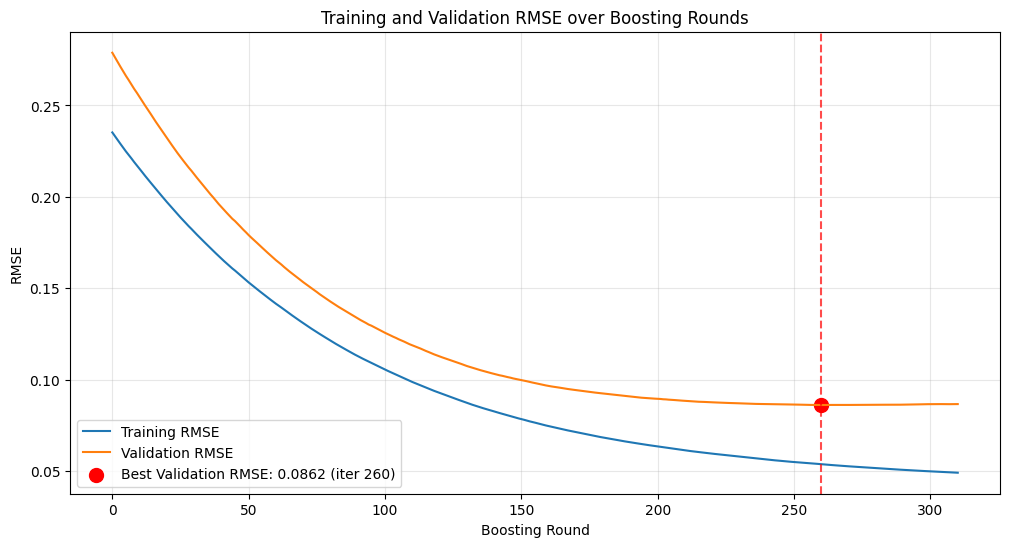


Evaluating on Validation Set...

验证集评估结果:
Validation - MSE: 34.86, RMSE: 5.90, CVRMSE: 24.57%, R2: 0.8650, Accuracy: 82.35%


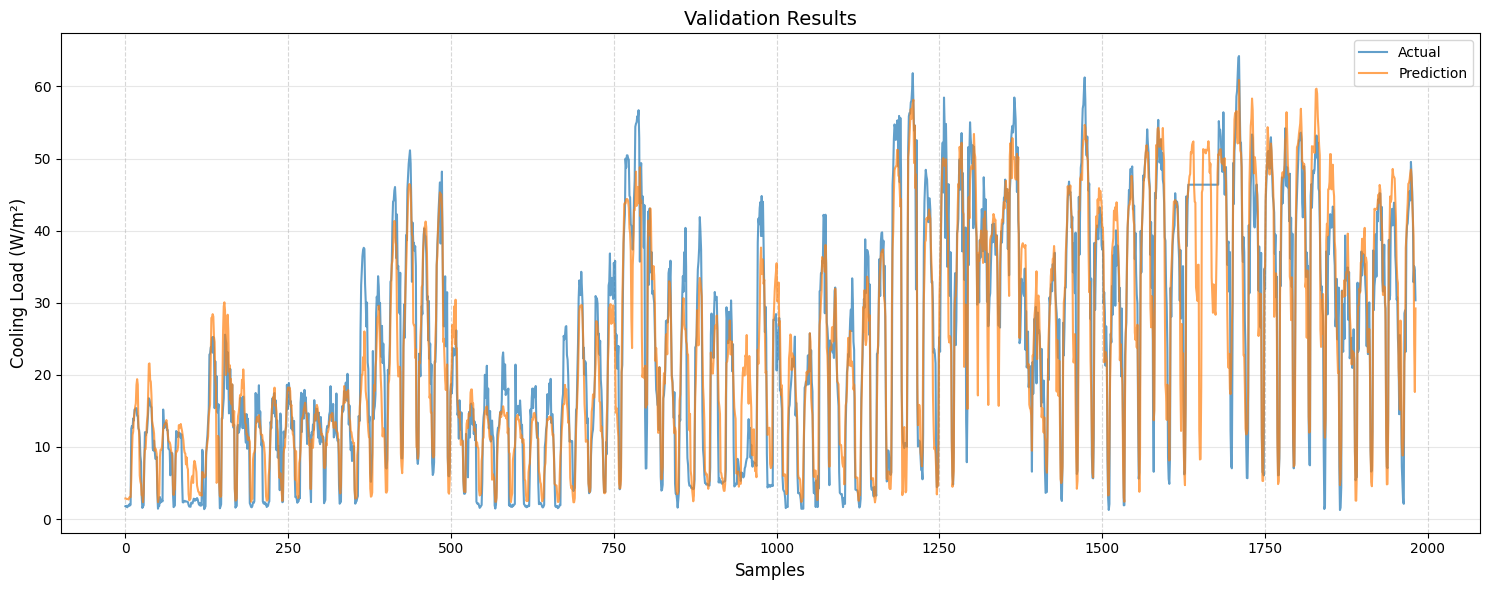


Evaluating on Test Set...

测试集评估结果:
Test - MSE: 30.55, RMSE: 5.53, CVRMSE: 19.44%, R2: 0.8474, Accuracy: 84.38%


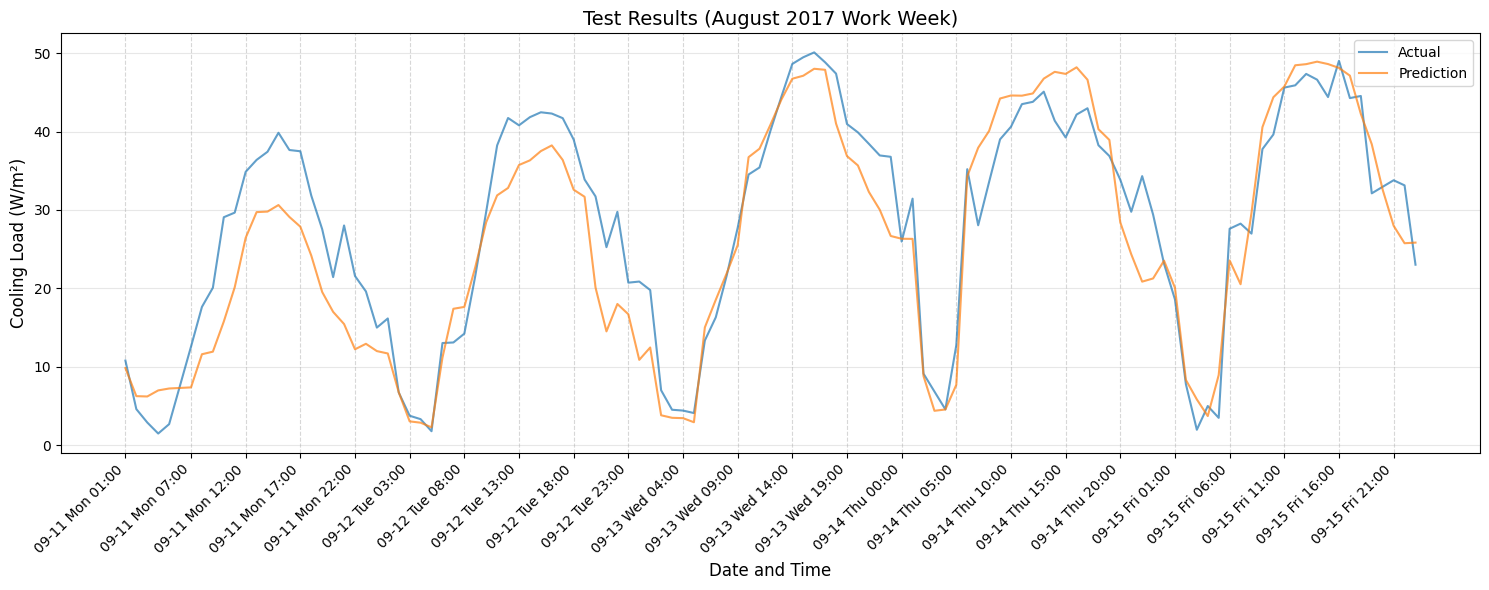

<Figure size 1200x800 with 0 Axes>

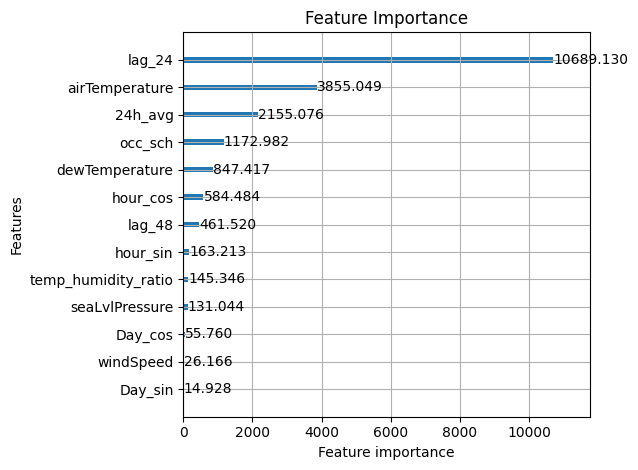

Model saved to 'E:/bishe/lightgbm_model.txt'

Test Set Details:
Start: 2017-09-11 01:00
End: 2017-09-15 23:00
Days: 5 days
Total hours: 118
Day types: Mon, Tue, Wed, Thu, Fri

Total execution time: 00h:00m:21.21s


In [3]:
# ==================== 辅助函数 ====================
def fill_lag_nan(df, ref_df, target_col):
    """填充滞后特征中的NaN值"""
    for col in df.columns:
        if 'lag_' in col:
            lag = int(col.split('_')[-1])
            last_valid = ref_df[target_col].iloc[-lag:].mean()
            df[col] = df[col].fillna(last_valid)
    return df

def clean_data(df):
    """数据清洗：处理NaN和Inf"""
    # 填充NaN
    df = df.fillna(method='ffill').fillna(method='bfill')
    
    # 处理无穷大值
    for col in df.columns:
        if df[col].dtype in [np.float64, np.float32]:
            df[col] = df[col].replace([np.inf, -np.inf], np.nan)
            df[col] = df[col].fillna(df[col].mean())
    return df

# ==================== 数据预处理 ====================
def load_and_preprocess():
    # 加载数据
    data = pd.read_csv(DATA_SAVE_PATH, parse_dates=['timestamp'])
    
    # 筛选目标建筑数据
    building_columns = [col for col in data.columns 
                       if col.startswith(f"{SITE_ID}_{BUILDING_TYPE}_")]
    other_buildings = [col for col in building_columns if col != TARGET]
    data = data.drop(columns=other_buildings)
    
    # 按月份划分数据集
    data = data.sort_values('timestamp')
    data['year_month'] = data['timestamp'].dt.to_period('M')
    unique_months = data['year_month'].unique().tolist()
    
    # 数据集划分
    train = data[data['year_month'].isin(unique_months[:15])]  # 前15个月
    val = data[data['year_month'].isin(unique_months[15:19])]  # 接下来5个月
    
    # 使用与LSTM相同的测试时间段
    test_start = pd.Timestamp('2017-09-11 00:00:00')
    test_end = pd.Timestamp('2017-09-16 00:00:00')
    test = data[(data['timestamp'] >= test_start) & (data['timestamp'] < test_end)]
    
    # 保存测试集时间戳
    test_timestamps = test['timestamp'].copy().reset_index(drop=True)

    # 保存验证集时间戳
    val_timestamps = val['timestamp'].copy().reset_index(drop=True)
    
    # 特征工程（与LSTM一致）
    def add_features(df, target_col):
        df = df.copy()
        # 时间特征
        df['Hour'] = df['timestamp'].dt.hour
        df['DayOfWeek'] = df['timestamp'].dt.dayofweek
        
        # 周期特征
        df['hour_sin'] = np.sin(2 * np.pi * df['Hour'] / 24)
        df['hour_cos'] = np.cos(2 * np.pi * df['Hour'] / 24)
        df['Day_sin'] = np.sin(2 * np.pi * df['DayOfWeek'] / 7)
        df['Day_cos'] = np.cos(2 * np.pi * df['DayOfWeek'] / 7)
        
        # 滞后特征
        for i in [24, 48]:
            df[f'lag_{i}'] = df[target_col].shift(i)
            
        # 移动平均特征
        #df['3h_avg'] = df[target_col].rolling(3, min_periods=1).mean()
        df['24h_avg'] = df[target_col].rolling(24, min_periods=1).mean()
        
        # 交叉特征
        df['temp_humidity_ratio'] = df['airTemperature'] / (df['dewTemperature'] + 1e-6)
        
        return df.drop(columns=['Hour', 'DayOfWeek','year_month'])
    
    # 应用特征工程
    train = add_features(train, TARGET)
    val = add_features(val, TARGET)
    test = add_features(test, TARGET)
    
    # 数据清洗
    train = clean_data(train)
    val = clean_data(val)
    test = clean_data(test)
    
    # 填充滞后特征缺失值
    val = fill_lag_nan(val, train, TARGET)
    test = fill_lag_nan(test, pd.concat([train, val]), TARGET)
    
    # 定义特征列（与LSTM一致）
    features = [
        'airTemperature', 'dewTemperature', 'windSpeed', 'seaLvlPressure', 'occ_sch',
        'hour_sin', 'hour_cos', 'Day_sin', 'Day_cos',
        #'lag_1', 'lag_2', 'lag_3',
        'lag_24', 'lag_48',
        #'3h_avg', 
        '24h_avg',
        'temp_humidity_ratio'
    ]
    
    # 检查特征是否存在
    missing_features = [f for f in features if f not in train.columns]
    if missing_features:
        print(f"警告: 以下特征不存在，已从列表中移除: {missing_features}")
        features = [f for f in features if f not in missing_features]
    
    # 使用MinMaxScaler进行归一化（与LSTM一致）
    scaler_x = MinMaxScaler(feature_range=(0, 1))
    scaler_y = MinMaxScaler(feature_range=(0, 1))
    
    # 只使用训练集拟合归一化器
    X_train_scaled = scaler_x.fit_transform(train[features])
    y_train_scaled = scaler_y.fit_transform(train[[TARGET]])
    
    X_val_scaled = scaler_x.transform(val[features])
    y_val_scaled = scaler_y.transform(val[[TARGET]])
    
    X_test_scaled = scaler_x.transform(test[features])
    y_test_scaled = scaler_y.transform(test[[TARGET]])
    
    # 转换为DataFrame并重置索引
    X_train = pd.DataFrame(X_train_scaled, columns=features).reset_index(drop=True)
    X_val = pd.DataFrame(X_val_scaled, columns=features).reset_index(drop=True)
    X_test = pd.DataFrame(X_test_scaled, columns=features).reset_index(drop=True)
    
    y_train = pd.Series(y_train_scaled.ravel()).reset_index(drop=True)
    y_val = pd.Series(y_val_scaled.ravel()).reset_index(drop=True)
    y_test = pd.Series(y_test_scaled.ravel()).reset_index(drop=True)
    
    # 筛选工作日数据（周一至周五）
    work_days_mask = (test_timestamps.dt.dayofweek >= 0) & (test_timestamps.dt.dayofweek <= 4)
    work_timestamps = test_timestamps[work_days_mask].reset_index(drop=True)
    
    # 应用工作日掩码（确保索引对齐）
    X_test = X_test.loc[work_days_mask.values].reset_index(drop=True)
    y_test = y_test.loc[work_days_mask.values].reset_index(drop=True)
    
    return (X_train, X_val, X_test, 
            y_train, y_val, y_test, 
            work_timestamps, scaler_y)

# ==================== 模型训练与评估 ====================
def train_model_with_history(X_train, y_train, X_val, y_val, params):
    """使用验证集训练模型并记录历史"""
    # 创建数据集
    train_data = lgb.Dataset(X_train, label=y_train)
    val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)
    
    # 确保参数中包含必要的设置
    params.setdefault('objective', 'regression')
    params.setdefault('metric', 'rmse')
    params.setdefault('verbosity', -1)
    
    # 训练模型并记录历史
    evals_result = {}
    model = lgb.train(
        params,
        train_data,
        num_boost_round=1000,
        valid_sets=[train_data, val_data],
        valid_names=['train', 'val'],
        callbacks=[
            lgb.early_stopping(50, verbose=True),
            lgb.record_evaluation(evals_result),
            lgb.log_evaluation(50)
        ]
    )
    return model, evals_result

def plot_training_history(evals_result, save_path=None):
    """绘制训练损失曲线"""
    if not evals_result:
        print("没有可用的评估结果来绘制训练曲线")
        return
    
    plt.figure(figsize=(12, 6))
    
    # 提取训练和验证损失
    train_loss = evals_result['train']['rmse']
    val_loss = evals_result['val']['rmse']
    
    # 绘制曲线
    plt.plot(train_loss, label='Training RMSE')
    plt.plot(val_loss, label='Validation RMSE')
    
    # 标记最佳点
    best_iter = np.argmin(val_loss)
    best_val_loss = val_loss[best_iter]
    plt.axvline(x=best_iter, color='r', linestyle='--', alpha=0.7)
    plt.scatter(best_iter, best_val_loss, color='red', s=100, 
                label=f'Best Validation RMSE: {best_val_loss:.4f} (iter {best_iter})')
    
    # 添加图表元素
    plt.title('Training and Validation RMSE over Boosting Rounds')
    plt.xlabel('Boosting Round')
    plt.ylabel('RMSE')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 保存和显示
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

if __name__ == "__main__":
    # 数据准备 - 修改接收变量数量
    results = load_and_preprocess()
    if len(results) == 8:
        X_train, X_val, X_test, y_train, y_val, y_test, test_timestamps, scaler_y = results
        # 添加缺失的验证集时间戳
        val_timestamps = None  # 稍后会在函数内部处理
    else:
        raise ValueError(f"Unexpected number of return values: {len(results)}")
    
    # 参数网格
    param_grid = {
        'learning_rate': [0.01],
        'num_leaves': [63, 127],
        'max_depth': [7, 9],
        'min_data_in_leaf': [30, 50],
        'lambda_l1': [0, 0.1],
        'lambda_l2': [0, 0.1],
        'n_estimators': [500],
        'feature_fraction': [0.7, 0.8]
    }
    
    # 网格搜索寻找最佳参数
    print("Starting grid search...")
    start_time = time()
    
    # 初始化模型
    model = lgb.LGBMRegressor(
        objective='regression',
        metric='rmse',
        random_state=42,
        verbosity=-1
    )
    
    # 时间序列交叉验证
    tscv = TimeSeriesSplit(n_splits=3)
    
    # 网格搜索
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=tscv,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1,
        verbose=2
    )
    
    grid_search.fit(X_train, y_train)
    grid_time = time() - start_time
    print(f"Grid search completed in {grid_time:.2f} seconds")
    
    # 输出最佳参数
    best_params = grid_search.best_params_
    print("\nBest Parameters:", best_params)
    
    # 确保基本参数设置正确
    best_params['objective'] = 'regression'
    best_params['metric'] = 'rmse'
    
    # 使用最佳参数训练模型
    print("\nTraining final model with best parameters...")
    train_start_time = time()
    final_model, evals_result = train_model_with_history(
        X_train, y_train, X_val, y_val, best_params
    )
    train_time = time() - train_start_time
    print(f"Model training completed in {train_time:.2f} seconds")
    
    # 绘制训练历史
    plot_training_history(evals_result, save_path="E:/bishe/lightgbm_training_history.png")
    
    # 验证集评估
    print("\nEvaluating on Validation Set...")
    y_val_pred = final_model.predict(X_val)
    
    # 反归一化
    y_val_actual = scaler_y.inverse_transform(y_val.values.reshape(-1, 1)).ravel()
    y_val_pred_actual = scaler_y.inverse_transform(y_val_pred.reshape(-1, 1)).ravel()
    
    # 计算指标
    RMSE = math.sqrt(mean_squared_error(y_val_actual, y_val_pred_actual))
    CVRMSE = RMSE / np.mean(y_val_actual) * 100
    MAE = mean_absolute_error(y_val_actual, y_val_pred_actual)
    MSE = mean_squared_error(y_val_actual, y_val_pred_actual)
    R2 = r2_score(y_val_actual, y_val_pred_actual)
    accuracy = (1 - MAE / np.mean(y_val_actual)) * 100
    
    print("\n验证集评估结果:")
    print("Validation - MSE: %.2f, RMSE: %.2f, CVRMSE: %.2f%%, R2: %.4f, Accuracy: %.2f%%" 
        % (MSE, RMSE, CVRMSE, R2, accuracy))

    # 绘制验证集结果（新增部分）
    # 创建验证集时间戳 - 如果没有从函数中获取
    if val_timestamps is None:
        # 创建简单的索引作为时间戳（实际应用中应使用真实时间戳）
        val_timestamps = pd.Series(range(len(y_val_actual)))
    
    plt.figure(figsize=(15, 6))
    plt.plot(val_timestamps, y_val_actual, label='Actual', alpha=0.7)
    plt.plot(val_timestamps, y_val_pred_actual, label='Prediction', alpha=0.7)
    
    # 如果val_timestamps是时间戳类型，则格式化日期标签
    if hasattr(val_timestamps, 'dt'):
        date_labels = val_timestamps.dt.strftime('%m-%d %a %H:%M')
        n = len(val_timestamps)
        step = max(1, n // 20)  # 最多显示20个标签
        
        # 设置x轴刻度和标签
        plt.xticks(ticks=val_timestamps[::step], 
                   labels=date_labels[::step], 
                   rotation=45, 
                   ha='right')
        
        plt.xlabel('Date and Time', fontsize=12)
    else:
        plt.xlabel('Samples', fontsize=12)
    
    # 添加网格线和标签
    plt.gca().xaxis.grid(True, which='major', linestyle='--', alpha=0.5)
    plt.gca().yaxis.grid(True, alpha=0.3)
    plt.ylabel('Cooling Load (W/m²)', fontsize=12)
    plt.title('Validation Results', fontsize=14)
    plt.legend()
    plt.tight_layout()
    
    # 保存高质量图像
    plt.savefig("E:/bishe/lightgbm_validation_results.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    # 测试集评估
    print("\nEvaluating on Test Set...")
    y_test_pred = final_model.predict(X_test)
    
    # 反归一化
    y_test_actual = scaler_y.inverse_transform(y_test.values.reshape(-1, 1)).ravel()
    y_test_pred_actual = scaler_y.inverse_transform(y_test_pred.reshape(-1, 1)).ravel()
    
    # 计算指标
    RMSE = math.sqrt(mean_squared_error(y_test_actual, y_test_pred_actual))
    CVRMSE = RMSE / np.mean(y_test_actual) * 100
    MAE = mean_absolute_error(y_test_actual, y_test_pred_actual)
    MSE = mean_squared_error(y_test_actual, y_test_pred_actual)
    R2 = r2_score(y_test_actual, y_test_pred_actual)
    accuracy = (1 - MAE / np.mean(y_test_actual)) * 100
    
    print("\n测试集评估结果:")
    print("Test - MSE: %.2f, RMSE: %.2f, CVRMSE: %.2f%%, R2: %.4f, Accuracy: %.2f%%" 
        % (MSE, RMSE, CVRMSE, R2, accuracy))

    # 绘制测试集结果
    plt.figure(figsize=(15, 6))
    plt.plot(test_timestamps, y_test_actual, label='Actual', alpha=0.7)
    plt.plot(test_timestamps, y_test_pred_actual, label='Prediction', alpha=0.7)
    
    # 如果test_timestamps是时间戳类型，则格式化日期标签
    if hasattr(test_timestamps, 'dt'):
        date_labels = test_timestamps.dt.strftime('%m-%d %a %H:%M')
        n = len(test_timestamps)
        step = max(1, n // 20)  # 最多显示20个标签
        
        # 设置x轴刻度和标签
        plt.xticks(ticks=test_timestamps[::step], 
                   labels=date_labels[::step], 
                   rotation=45, 
                   ha='right')
        
        plt.xlabel('Date and Time', fontsize=12)
    else:
        plt.xlabel('Samples', fontsize=12)
    
    # 添加网格线和标签
    plt.gca().xaxis.grid(True, which='major', linestyle='--', alpha=0.5)
    plt.gca().yaxis.grid(True, alpha=0.3)
    plt.ylabel('Cooling Load (W/m²)', fontsize=12)
    plt.title('Test Results (August 2017 Work Week)', fontsize=14)
    plt.legend()
    plt.tight_layout()
    
    # 保存高质量图像
    plt.savefig("E:/bishe/lightgbm_test_results.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    # 特征重要性分析
    plt.figure(figsize=(12, 8))
    lgb.plot_importance(final_model, title='Feature Importance', max_num_features=20, importance_type='gain')
    plt.tight_layout()
    plt.savefig("E:/bishe/lightgbm_feature_importance.png", dpi=300)
    plt.show()
    
    # 保存模型
    final_model.save_model('E:/bishe/lightgbm_model.txt')
    print("Model saved to 'E:/bishe/lightgbm_model.txt'")
    
    # 输出测试集详细信息
    if hasattr(test_timestamps, 'dt'):
        print("\nTest Set Details:")
        print(f"Start: {test_timestamps.min().strftime('%Y-%m-%d %H:%M')}")
        print(f"End: {test_timestamps.max().strftime('%Y-%m-%d %H:%M')}")
        print(f"Days: {test_timestamps.dt.date.nunique()} days")
        print(f"Total hours: {len(test_timestamps)}")
        print(f"Day types: {', '.join(test_timestamps.dt.strftime('%a').unique())}")
    else:
        print(f"\nTest Samples: {len(test_timestamps)}")
    
    # 计算并打印总时间
    total_time = time() - start_time
    hours, rem = divmod(total_time, 3600)
    minutes, seconds = divmod(rem, 60)
    print(f"\nTotal execution time: {int(hours):02d}h:{int(minutes):02d}m:{seconds:.2f}s")